In [29]:
import os, argparse, typing
os.chdir("../")

import numpy as np
import pandas as pd
import scanpy as sc
import torch 
from torch import nn
from torch import optim
from torch.utils.data import DataLoader
from torch.optim import lr_scheduler
from functools import partial
import pytorch_lightning as pl
from pytorch_lightning import callbacks 
from pytorch_lightning import loggers as pl_loggers

from PINN import models as models
from PINN import reader 
from PINN import functions as fns

In [30]:
import matplotlib.pyplot as plt
from PINN import pl
from importlib import reload

In [35]:
reload(reader)

<module 'PINN.reader' from '/ssd/users/Wergillius/Project/PINN_dynamics/PINN/reader.py'>

In [3]:
# load the anndata
ery_mk_ad = sc.read_h5ad("data/ery_mk.h5ad")

In [36]:
train_DS = reader.HigDim_AnnDS(AnnData=ery_mk_ad, n_dimension = 5, 
                               cellstate_key="DM_EigenVectors",  #'DM_EigenVector'
                                     nearby_cellstate=1, 
                                    collocation_points=300)



In [5]:
test_ckpt = "logs/ery_mk-DM_EigenVectors_multiBnch/MLP/lightning_logs/version_4/checkpoints/epoch=37-total_loss=0.00000260.ckpt"

In [6]:
def pred(modelvx, train_DS, device= 'cuda:7'):

    relu_f = nn.ReLU()
    modelvx = modelvx.to(device)
    
    with torch.no_grad():
        u_pred_b = modelvx(train_DS.s.to(device), train_DS.t_b.to(device))
        u_pred_b = relu_f(u_pred_b)
        
    
    u_pred_b = u_pred_b.cpu()
    u_b = train_DS.u_b.cpu()

    return u_b, u_pred_b

In [7]:
def load_model(ckptvx):
        
    test_ckpt = torch.load(ckptvx)
    model = models.MLP(**test_ckpt['hyper_parameters'])
    model.load_state_dict(test_ckpt['state_dict'])
    return model

# load test model

In [9]:
test_ckpt = "logs/ery_mk-DM_EigenVectors_multiBnch/MLP/lightning_logs/version_4/checkpoints/epoch=37-total_loss=0.00000260.ckpt"

In [8]:
model = load_model(test_ckpt)

In [45]:
# predict
u, u_pred = pred(model, train_DS)

# reshape to [time, cell]
u = u.cpu().numpy().reshape(9,-1)
u_pred = u_pred.cpu().numpy().reshape(9,-1)

In [61]:
for i, t in enumerate(train_DS.popD['t']):
    ery_mk_ad.obs[f'Day{t}_u'] = u[i]
    ery_mk_ad.obs[f'Day{t}_MLP_upred'] = u_pred[i]

In [ ]:
from Explore_Notebook.density import plotting_fn as pl_fn

In [75]:
reload(pl_fn)

<module 'Explore_Notebook.density.plotting_fn' from '/ssd/users/Wergillius/Project/PINN_dynamics/Explore_Notebook/density/plotting_fn.py'>

(<Figure size 3000x200 with 18 Axes>,
 array([<Axes: title={'center': 'scaled pseudotime d3'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'scaled pseudotime d7'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'scaled pseudotime d12'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'scaled pseudotime d27'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'scaled pseudotime d49'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'scaled pseudotime d76'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'scaled pseudotime d112'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'scaled pseudotime d161'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'scaled pseudotime d269'}, xlabel='UMAP1', ylabel='UMAP2'>],
       dtype=object))

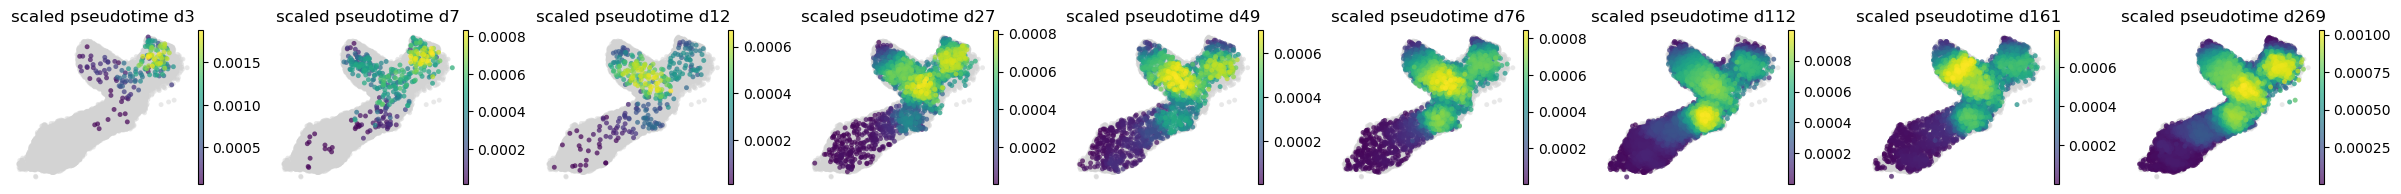

In [76]:
pl_fn.umap_by_time(lambda x: f'Day{x}_u', ery_mk_ad)

In [49]:
train_DS.popD['t']

array([  3,   7,  12,  27,  49,  76, 112, 161, 269])

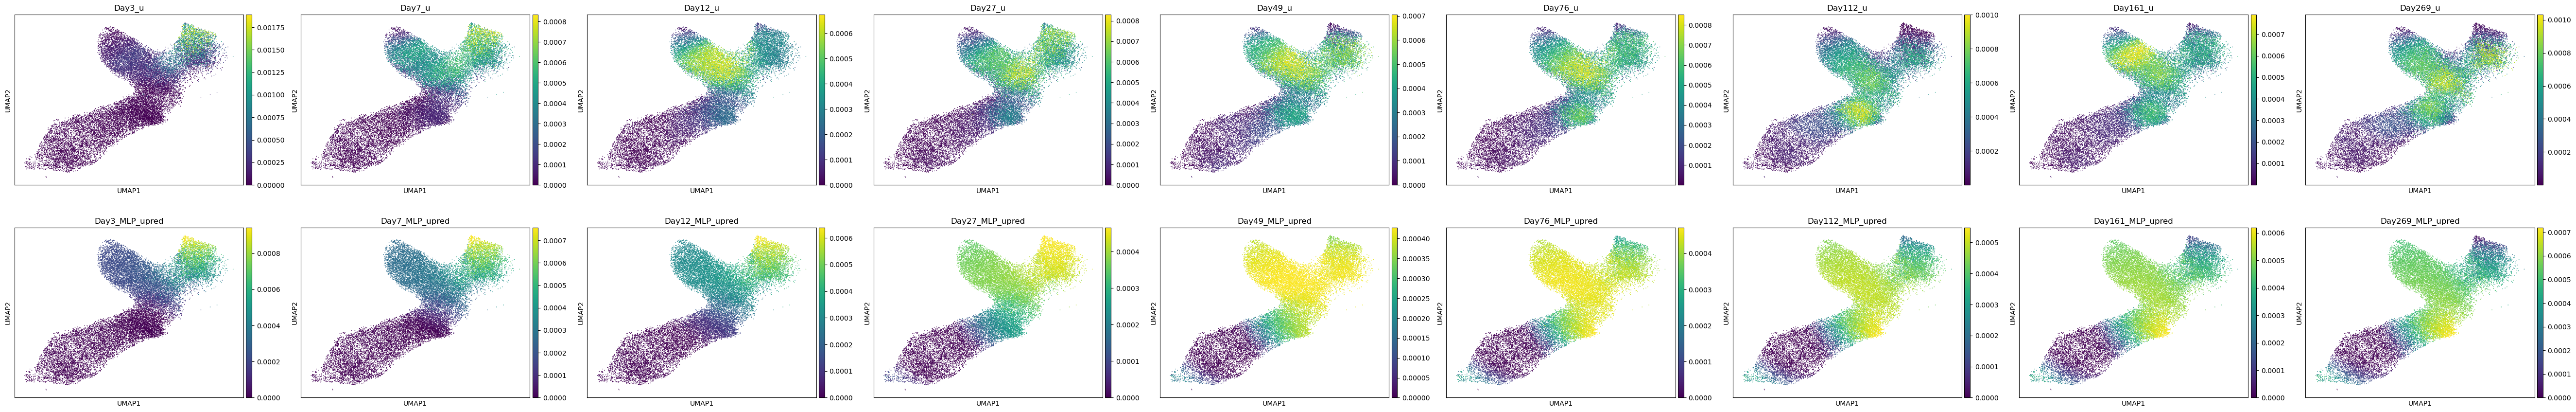

In [63]:
color_cols = [f'Day{t}_u' for t in train_DS.popD['t']] + [f'Day{t}_MLP_upred' for t in train_DS.popD['t']]
sc.pl.umap(ery_mk_ad, color=color_cols, ncols=9)